In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.optimize import fmin_slsqp
from toolz import reduce, partial
import pyfixest as pf
from pyfixest import iplot
import random
from scpi_pkg.scdata import scdata
from scpi_pkg.scest import scest
from scpi_pkg.scplot import scplot

ModuleNotFoundError: No module named 'pandas'

In [44]:
aqi_data = pd.read_csv("aqi_daily_1980_to_2021.csv")

In [45]:
rb_states = [
    "Illinois",
    "Indiana",
    "Michigan",
    "New York",
    "Ohio",
    "Pennsylvania",
    "West Virginia",
    "Wisconsin"
]

res_counties = ["Lake", "Marion", "Kent", "Macomb", "Wayne", "Monroe", "Hamilton", "Montgomery"]

rb_aqi_data = aqi_data[aqi_data["State Name"].isin(rb_states) & aqi_data["County Name"].isin(res_counties)]

rb_aqi_data["Date"] = pd.to_datetime(rb_aqi_data["Date"])
rb_aqi_data["year"] = rb_aqi_data["Date"].dt.year

rb_aqi_summary = (rb_aqi_data.groupby(["County Name", "Defining Parameter", "year"], as_index=False)["AQI"]
                  .mean().rename(columns={"AQI": "avg_aqi"}))

rb_aqi_summary = rb_aqi_summary[(rb_aqi_summary["year"] >= 2001) & (rb_aqi_summary["year"] <= 2010)]
rb_aqi_summary
#rb_aqi_summary.to_csv("aqi_summary.csv", index=False)

/var/folders/g0/1_gj42z94q93wf4k_ck_hqd40000gn/T/ipykernel_35442/3952890171.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rb_aqi_data["Date"] = pd.to_datetime(rb_aqi_data["Date"])
/var/folders/g0/1_gj42z94q93wf4k_ck_hqd40000gn/T/ipykernel_35442/3952890171.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rb_aqi_data["year"] = rb_aqi_data["Date"].dt.year


,County Name,Defining Parameter,year,avg_aqi
16,Hamilton,CO,2006,33.000000
40,Hamilton,NO2,2001,40.529412
41,Hamilton,NO2,2002,38.062500
42,Hamilton,NO2,2003,44.448276
43,Hamilton,NO2,2004,43.225806
...,...,...,...,...
1384,Wayne,SO2,2006,80.397436
1385,Wayne,SO2,2007,79.148148
1386,Wayne,SO2,2008,77.246377
1387,Wayne,SO2,2009,67.681818


In [46]:
rb_aqi_summary["treated"] = (rb_aqi_summary["County Name"] == "Wayne").astype(int)

rb_aqi_wide = (
    rb_aqi_summary
      .pivot_table(
          index=["County Name", "year"],     
          columns="Defining Parameter",
          values="avg_aqi",
          aggfunc="mean"
      )
      .reset_index()
)
rb_aqi_wide.columns.name = None

rb_aqi_wide["treated"] = (rb_aqi_wide["County Name"] == "Wayne").astype(int)




In [47]:
rb_aqi_wide

,County Name,year,CO,NO2,Ozone,PM10,PM2.5,SO2,treated
0,Hamilton,2001,NaN,40.529412,52.940547,NaN,66.582011,98.904110,0
1,Hamilton,2002,NaN,38.062500,59.468750,NaN,60.465608,89.337349,0
2,Hamilton,2003,NaN,44.448276,54.018703,NaN,61.238318,78.043478,0
3,Hamilton,2004,NaN,43.225806,48.139334,NaN,60.497110,83.181818,0
4,Hamilton,2005,NaN,38.010526,54.101176,NaN,67.382979,67.258427,0
...,...,...,...,...,...,...,...,...,...
75,Wayne,2006,NaN,31.227273,41.375862,41.181818,65.434286,80.397436,1
76,Wayne,2007,NaN,33.352941,53.932075,47.750000,59.970732,79.148148,1
77,Wayne,2008,NaN,27.925926,44.460526,29.142857,55.994536,77.246377,1
78,Wayne,2009,NaN,31.555556,39.028125,41.000000,52.792929,67.681818,1


In [48]:
pollutants = [c for c in rb_aqi_wide.columns if c not in ["County Name", "year", "treated"]] 

#checking which pollutants have complete data across all counties and years
available_thru_out = [
    c for c in pollutants
    if rb_aqi_wide[c].notna().all()
]

print(available_thru_out)
rb_aqi_pmo = rb_aqi_wide[["County Name", "year", "treated", "Ozone", "PM2.5"]].copy()
rb_aqi_pmo

['Ozone', 'PM2.5']


,County Name,year,treated,Ozone,PM2.5
0,Hamilton,2001,0,52.940547,66.582011
1,Hamilton,2002,0,59.468750,60.465608
2,Hamilton,2003,0,54.018703,61.238318
3,Hamilton,2004,0,48.139334,60.497110
4,Hamilton,2005,0,54.101176,67.382979
...,...,...,...,...,...
75,Wayne,2006,1,41.375862,65.434286
76,Wayne,2007,1,53.932075,59.970732
77,Wayne,2008,1,44.460526,55.994536
78,Wayne,2009,1,39.028125,52.792929


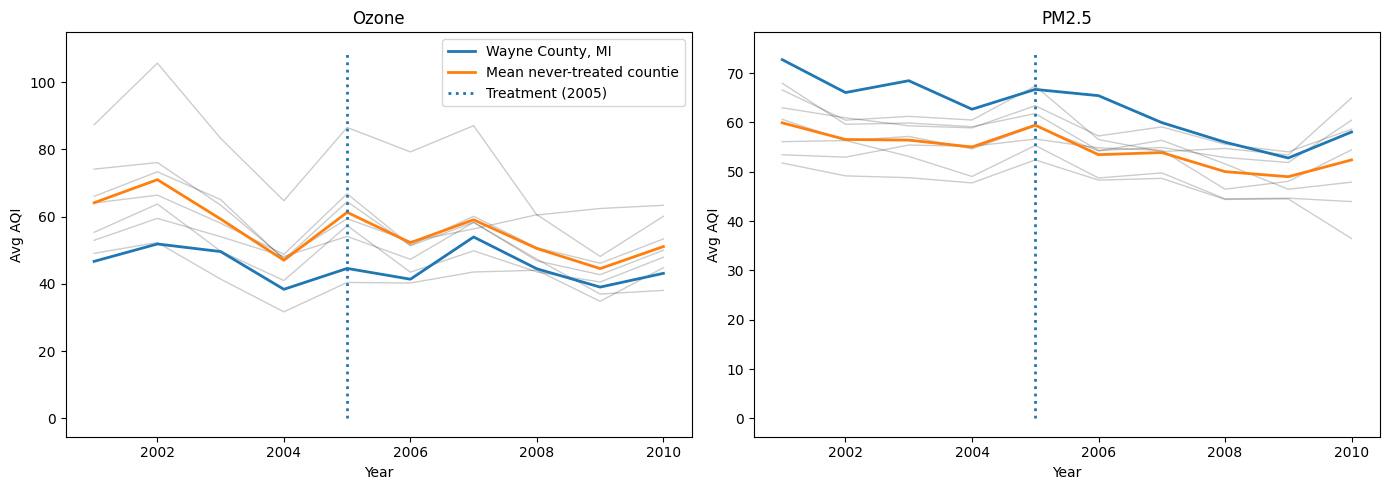

In [49]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for ax, col in zip(axes, ["Ozone", "PM2.5"]):
    for _, gdf in rb_aqi_pmo.groupby("County Name"):
        ax.plot(gdf["year"], gdf[col], alpha=0.2, lw=1, color="k")
    wayne = rb_aqi_pmo[rb_aqi_pmo["County Name"] == "Wayne"]
    ax.plot(wayne["year"], wayne[col], label="Wayne County, MI", lw=2)
    (
        rb_aqi_pmo[rb_aqi_pmo["County Name"] != "Wayne"]
        .groupby("year")[col]
        .mean()
        .plot(ax=ax, label="Mean never-treated countie", lw=2)
    )
    ymax = ax.get_ylim()[1]
    ax.vlines(x=2005, ymin=0, ymax=ymax, linestyle=":", lw=2, label="Treatment (2005)")
    ax.set_title(col)
    ax.set_xlabel("Year")
    ax.set_ylabel("Avg AQI")

axes[0].legend()
plt.tight_layout()
plt.show()


In [50]:
rb_aqi_pmo.rename(columns={
    "County Name": "county",
    "PM2.5": "pm25",
    "Ozone": "ozone",
}, inplace=True)# reformatting the columns so that twfe doesnt complain

pm25_twfe = pf.feols(
    'pm25 ~ i(year, treated, ref=2004) | Q("county") + year',
    rb_aqi_pmo,
    vcov={"CRV1": "county"},
)

ozone_twfe = pf.feols(
    'ozone ~ i(year, treated, ref=2004) | Q("county") + year',
    rb_aqi_pmo,
    vcov={"CRV1": "county"},
)

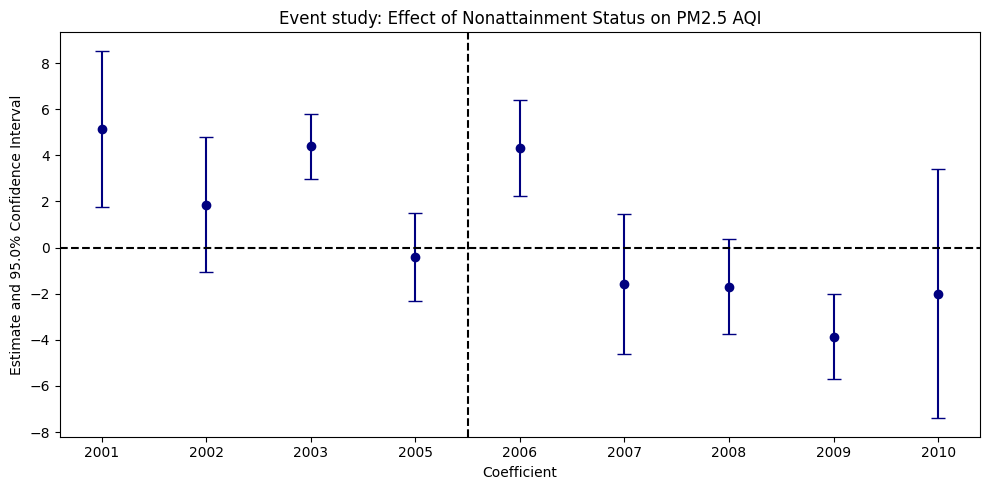

In [51]:
pm25_twfe.iplot(
    coord_flip=False,
    figsize=(10, 5),
    yintercept=0,  
    cat_template="{value_int}",
    xintercept=3.5,
    title="Event study: Effect of Nonattainment Status on PM2.5 AQI",
)

## PM2.5 Synthetic Control 

In [54]:
treat_year = 2005
features = ["pm25"]

inverted = (
    rb_aqi_pmo.query("year < @treat_year")      
          .pivot(index="county", columns="year")[features]  
          .T                               
)
inverted

county      Hamilton       Kent       Lake     Macomb     Marion     Monroe  \
     year                                                                     
pm25 2001  66.582011  53.450000  67.957958  51.773333  62.979228  56.105882   
     2002  60.465608  52.972093  59.620112  49.168831  60.948949  56.337143   
     2003  61.238318  55.419355  59.887372  48.802817  59.324786  53.120879   
     2004  60.497110  55.163366  59.139394  47.743902  58.903323  49.048913   

county     Montgomery      Wayne  
     year                         
pm25 2001   60.635802  72.735135  
     2002   56.322086  66.065990  
     2003   57.166172  68.468085  
     2004   54.644068  62.679245

In [61]:
X1 = inverted["Wayne"].values               

X0_names = [c for c in inverted.columns if c != "Wayne"]
X0 = inverted[X0_names].values              

def loss_w(W, X0, X1) -> float:
    diff = (X1 - X0.dot(W)) 
    return np.mean(diff**2)

def get_w(X0, X1):
    w_start = [1 / X0.shape[1]] * X0.shape[1]   
    weights = fmin_slsqp(
        partial(loss_w, X0=X0, X1=X1),
        np.array(w_start),
        f_eqcons=lambda x: np.sum(x) - 1,      
        bounds=[(0.0, 1.0)] * len(w_start),    
        disp=False
    )
    return weights

wayne_weights = get_w(X0, X1)


wayne_weights_series = pd.Series(wayne_weights, index=X0_names, name="weight")
print(wayne_weights_series.sort_values(ascending=False))

wayne_weights.sum()


Hamilton      1.000000e+00
Monroe        5.985151e-13
Montgomery    1.943567e-13
Marion        1.694502e-13
Kent          0.000000e+00
Lake          0.000000e+00
Macomb        0.000000e+00
Name: weight, dtype: float64


np.float64(1.0000000000007117)

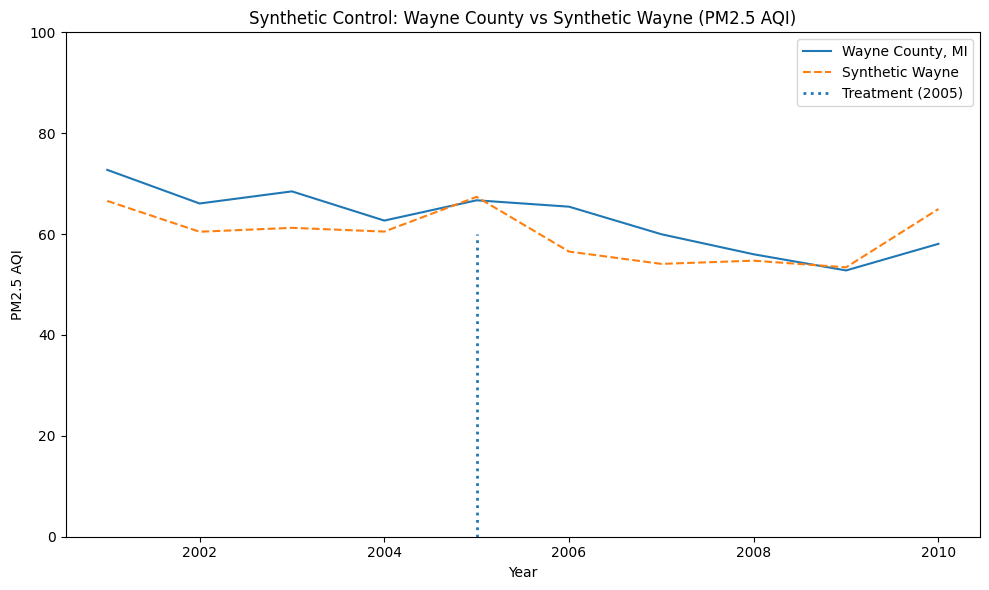

In [69]:
X0_panel = (
    rb_aqi_pmo.query('county != "Wayne"')
          .pivot(index="year", columns="county")["pm25"]
          .sort_index()
)

X0_panel = X0_panel[X0_names]

wayne_synth = X0_panel.values.dot(wayne_weights)

wayne_actual = (
    rb_aqi_pmo[rb_aqi_pmo["county"] == "Wayne"]
    .sort_values("year")
    .set_index("year")["pm25"]
)

years = X0_panel.index  

# Plot the results

plt.figure(figsize=(10, 6))
plt.plot(wayne_actual.index, wayne_actual.values, label="Wayne County, MI")
plt.plot(years, wayne_synth, label="Synthetic Wayne", linestyle="--")

plt.vlines(x=2005, ymin=0, ymax=60, linestyle=":", lw=2, label="Treatment (2005)")
plt.ylim(0, 100)

plt.ylabel("PM2.5 AQI")
plt.xlabel("Year")
plt.title("Synthetic Control: Wayne County vs Synthetic Wayne (PM2.5 AQI)")
plt.legend()
plt.tight_layout()
plt.show()
